In [31]:
import torch
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import datasets
from torchvision.transforms import ToTensor, transforms
import matplotlib.pyplot as plt
import numpy as np

import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

In [32]:
print("Torch version:", torch.__version__)
print("CUDA version:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Torch version: 2.9.1+cu126
CUDA version: 12.6
CUDA available: True
GPU: NVIDIA GeForce RTX 3070 Ti


# Load CIFAR-10

In [33]:
transform = transforms.Compose([
    transforms.ToTensor()
])

In [34]:
train_data = datasets.CIFAR10(
    root="data",
    train=True,
    download=True,
    transform=ToTensor()
)

test_data = datasets.CIFAR10(
    root="data",
    train=False,
    download=True,
    transform=ToTensor()
)

### train val split

In [35]:
train_size = int(0.8 * len(train_data))
val_size = len(train_data) - train_size

train_dataset, val_dataset = random_split(train_data, [train_size, val_size])

In [36]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False)

In [37]:
print(len(train_loader.dataset))
print(len(val_loader.dataset))
print(len(test_loader.dataset))

40000
10000
10000


# Baseline Lenet-5

In [38]:
class LeNet5(nn.Module):

    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(3, 6, kernel_size=5)
        self.pool = nn.MaxPool2d(2, 2)

        self.conv2 = nn.Conv2d(6, 16, kernel_size=5)

        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

        self._initialize_weights()

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d) or isinstance(m, nn.Linear):
                nn.init.kaiming_uniform_(m.weight)

    def forward(self, x):

        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))

        x = torch.flatten(x, 1)

        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))

        x = self.fc3(x)

        return F.softmax(x, dim=1)

In [39]:
model = LeNet5()

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=0.001)

# Lenet filters added

In [40]:
class LeNet5_Filters(nn.Module):

    def __init__(self):
        super().__init__()

        #increase the number of filters in the convolutional layers to 32 and 64 respectively
        self.conv1 = nn.Conv2d(3, 32, 5)
        self.pool = nn.MaxPool2d(2,2)
        self.conv2 = nn.Conv2d(32, 64, 5)

        self.fc1 = nn.Linear(64*5*5,120)
        self.fc2 = nn.Linear(120,84)
        self.fc3 = nn.Linear(84,10)

        self._initialize_weights()

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d) or isinstance(m, nn.Linear):
                nn.init.kaiming_uniform_(m.weight)

    def forward(self,x):

        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))

        x = torch.flatten(x,1)

        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))

        x = self.fc3(x)

        return F.softmax(x, dim=1)

# Lenet filters + dropout

In [41]:
class LeNet5_Dropout(nn.Module):

    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(3, 32, 5)
        self.pool = nn.MaxPool2d(2,2)
        self.conv2 = nn.Conv2d(32, 64, 5)

        self.fc1 = nn.Linear(64*5*5,120)
        self.fc2 = nn.Linear(120,84)
        self.fc3 = nn.Linear(84,10)

        #dropout layer with 0.5 dropout rate
        self.dropout = nn.Dropout(0.5)

        self._initialize_weights()

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d) or isinstance(m, nn.Linear):
                nn.init.kaiming_uniform_(m.weight)

    def forward(self,x):

        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))

        x = torch.flatten(x,1)

        #apply dropout after the first two fully connected layers
        x = self.dropout(F.relu(self.fc1(x)))
        x = self.dropout(F.relu(self.fc2(x)))

        x = self.fc3(x)

        return F.softmax(x, dim=1)

# Train models

In [42]:
class EarlyStopping:
    def __init__(self, patience=5, min_delta=0):
        self.patience = patience
        self.min_delta = min_delta
        
        self.best_loss = float("inf")
        self.counter = 0
        self.early_stop = False
        
        self.best_weights = None

    def __call__(self, val_loss, model):
        
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
            
            # store best weights in memory
            self.best_weights = model.state_dict()
        
        else:
            self.counter += 1
            
            if self.counter >= self.patience:
                self.early_stop = True

In [43]:
def train_epoch(model, train_loader, criterion, optimizer, device='cpu'):
    model.train()
    total_loss = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    return total_loss / len(train_loader)

def validate(model, val_loader, criterion, device='cpu'):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    return total_loss / len(val_loader), correct / total

In [44]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")
models = {
    'LeNet5': LeNet5(),
    'LeNet5_Filters': LeNet5_Filters(),
    'LeNet5_Dropout': LeNet5_Dropout()
}

epochs = 70
history = {}

for model_name, model_instance in models.items():
    print(f"\nTraining {model_name}...")
    
    model_instance.to(device)
    optimizer = optim.Adam(model_instance.parameters(), lr=0.001)

    early_stopping = EarlyStopping(
        patience=10,
    )

    train_losses, val_losses, val_accuracies = [], [], []

    for epoch in range(epochs):

        train_loss = train_epoch(model_instance, train_loader, criterion, optimizer, device)
        val_loss, val_acc = validate(model_instance, val_loader, criterion, device)

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        val_accuracies.append(val_acc)

        print(
            f"Epoch {epoch+1}/{epochs} - "
            f"Train Loss: {train_loss:.4f}, "
            f"Val Loss: {val_loss:.4f}, "
            f"Val Acc: {val_acc:.4f}"
        )

        # Early stopping check
        early_stopping(val_loss, model_instance)

        if early_stopping.early_stop:
            print(f"Early stopping triggered for {model_name}")
            break

    # load best model
    model_instance.load_state_dict(early_stopping.best_weights)

    history[model_name] = {
        'train_loss': train_losses,
        'val_loss': val_losses,
        'val_acc': val_accuracies
    }

print("\nTraining complete!")

Using device: cuda

Training LeNet5...
Epoch 1/70 - Train Loss: 2.1397, Val Loss: 2.0728, Val Acc: 0.3818
Epoch 2/70 - Train Loss: 2.0426, Val Loss: 2.0124, Val Acc: 0.4435
Epoch 3/70 - Train Loss: 1.9930, Val Loss: 1.9868, Val Acc: 0.4690
Epoch 4/70 - Train Loss: 1.9623, Val Loss: 1.9804, Val Acc: 0.4758
Epoch 5/70 - Train Loss: 1.9418, Val Loss: 1.9652, Val Acc: 0.4908
Epoch 6/70 - Train Loss: 1.9216, Val Loss: 1.9417, Val Acc: 0.5144
Epoch 7/70 - Train Loss: 1.9089, Val Loss: 1.9298, Val Acc: 0.5279
Epoch 8/70 - Train Loss: 1.8993, Val Loss: 1.9313, Val Acc: 0.5245
Epoch 9/70 - Train Loss: 1.8884, Val Loss: 1.9281, Val Acc: 0.5283
Epoch 10/70 - Train Loss: 1.8758, Val Loss: 1.9305, Val Acc: 0.5256
Epoch 11/70 - Train Loss: 1.8723, Val Loss: 1.9405, Val Acc: 0.5157
Epoch 12/70 - Train Loss: 1.8630, Val Loss: 1.9225, Val Acc: 0.5347
Epoch 13/70 - Train Loss: 1.8591, Val Loss: 1.9189, Val Acc: 0.5385
Epoch 14/70 - Train Loss: 1.8542, Val Loss: 1.9191, Val Acc: 0.5380
Epoch 15/70 - Trai

In [45]:
import json
with open('training_history.json', 'w') as f:
    json.dump(history, f)

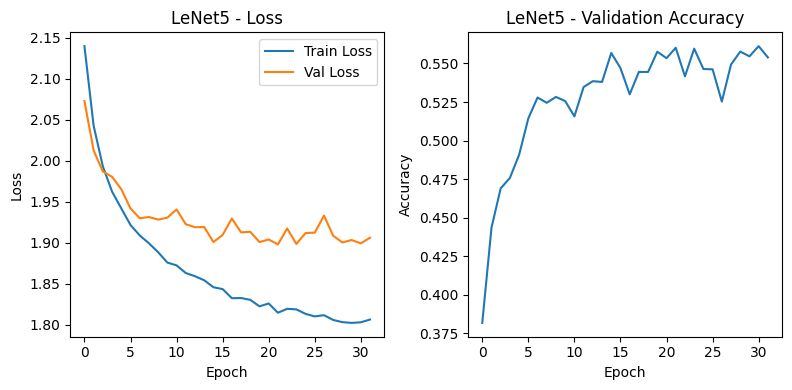

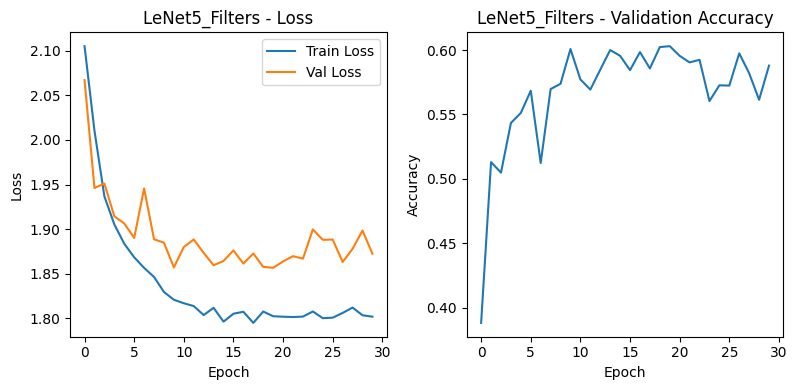

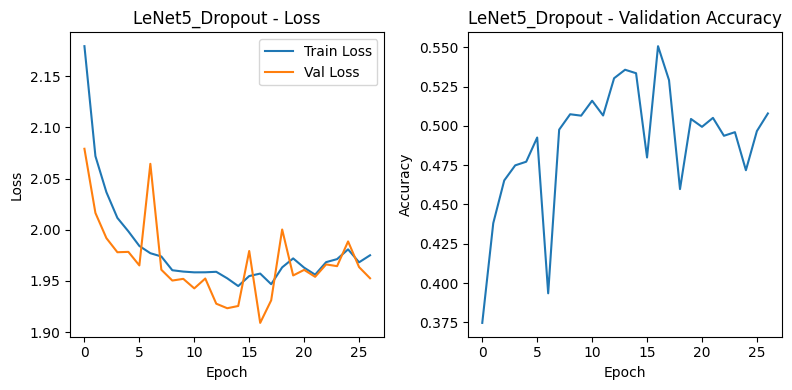

In [46]:
for model_name, data in history.items():
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 3, 1)
    plt.plot(data['train_loss'], label='Train Loss')
    plt.plot(data['val_loss'], label='Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(f'{model_name} - Loss')
    plt.legend()
    
    plt.subplot(1, 3, 2)
    plt.plot(data['val_acc'])
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title(f'{model_name} - Validation Accuracy')
    
    plt.tight_layout()
    plt.show()